In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [6]:
x = np.linspace(1, 10, 10)
y = x * 2 + np.random.normal(-0.5, 0.5, 10)
print(x, y, sep='\n')

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 1.36742276  2.30660329  6.19348677  7.77058553 10.02091601 12.51450724
 13.41400891 15.52137147 17.22024267 19.72744566]


Text(0, 0.5, 'y')

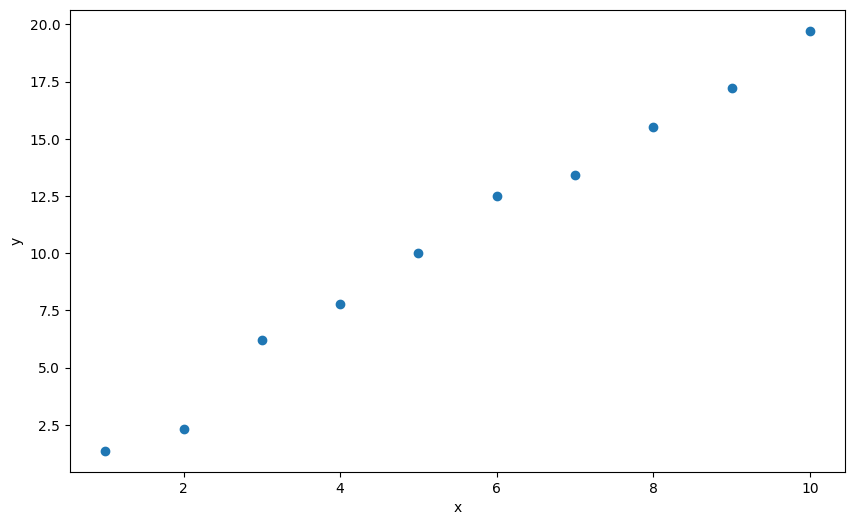

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')

In [13]:
r = stats.pearsonr(x, y)
print(f'{r[0]:.3f}')

0.995


In [21]:
price_changes = np.linspace(-25, 25, 11)
demands = 100 - 5 * price_changes + np.random.normal(0, 5, 11)
print(price_changes)
print(demands)

[-25. -20. -15. -10.  -5.   0.   5.  10.  15.  20.  25.]
[232.3642747  199.13839282 180.6650967  151.64950925 120.60889628
  91.55712697  85.97149423  46.87524755  20.8121872    4.82702867
 -28.00743079]


Text(0, 0.5, 'demands')

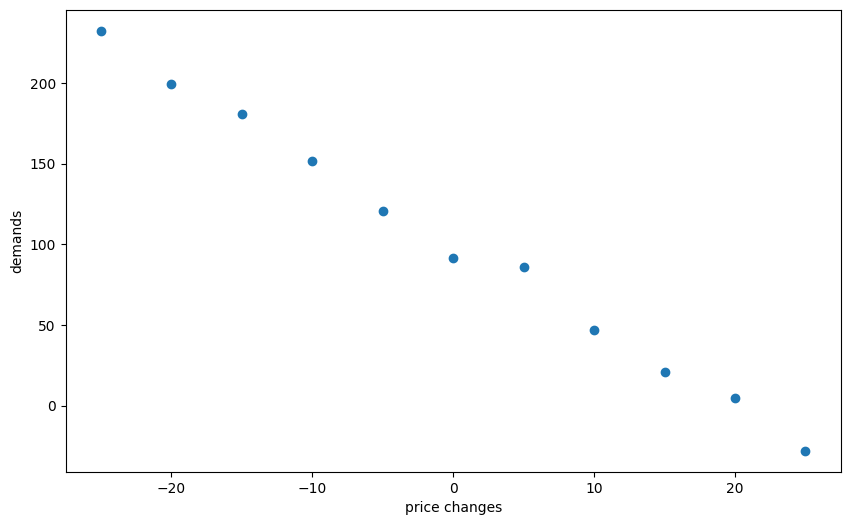

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(price_changes, demands, 'o')
plt.xlabel('price changes')
plt.ylabel('demands')

In [23]:
r = stats.pearsonr(price_changes, demands)
print(f'{r[0]:.3f}')

-0.998


In [24]:
df_admission = pd.read_csv('df.csv')
df_admission.head()

,ID,Name,State,Region,Applications,Admissions,Admission Rate,Enrollment,SATVR75,SATMT75,ACTEN75,ACTMT75
0,100654,Alabama A & M University,Alabama,Southeast,6560,4697,0.716006,1459,520.0,510.0,20.0,18.0
1,100663,University of Alabama at Birmingham,Alabama,Southeast,11906,10541,0.885352,2361,680.0,708.0,33.0,28.0
2,100706,University of Alabama in Huntsville,Alabama,Southeast,5781,4259,0.736724,1191,700.0,720.0,32.0,29.0
3,100724,Alabama State University,Alabama,Southeast,5974,5854,0.979913,797,534.0,516.0,22.0,19.0
4,100751,The University of Alabama,Alabama,Southeast,42421,33472,0.789043,7540,680.0,690.0,33.0,28.0


In [25]:
df_admission.describe()

,ID,Applications,Admissions,Admission Rate,Enrollment,SATVR75,SATMT75,ACTEN75,ACTMT75
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,925.000000,926.000000,874.000000,873.000000
mean,189796.284271,8731.049062,5244.271284,0.723308,1109.193362,632.144865,628.197624,27.462243,26.317297
std,60269.863552,13907.871240,7129.348144,0.211089,1563.206267,62.272726,72.076722,4.661418,3.778426
min,100654.000000,113.000000,111.000000,0.010229,100.000000,420.000000,380.000000,13.000000,7.000000
25%,153438.750000,1715.000000,1208.250000,0.633306,271.000000,590.000000,580.000000,24.000000,24.000000
50%,187546.000000,3797.000000,2602.000000,0.773564,511.000000,630.000000,611.500000,27.000000,26.000000
75%,216537.500000,9258.750000,6078.750000,0.872853,1224.000000,670.000000,670.000000,31.000000,28.000000
max,496681.000000,139489.000000,89207.000000,1.000000,15785.000000,790.000000,800.000000,36.000000,36.000000


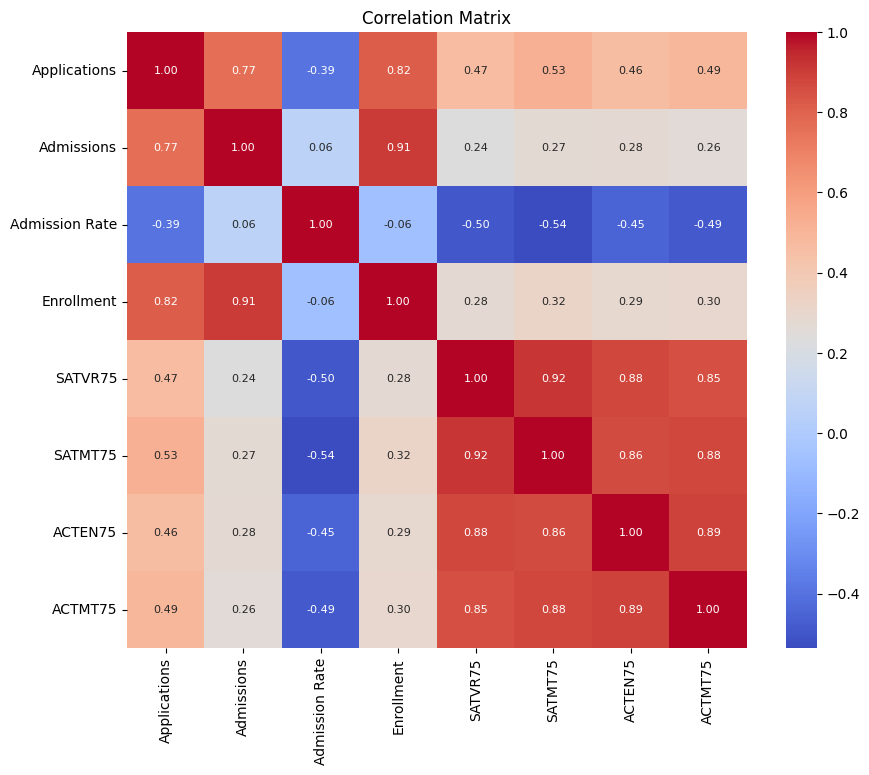

In [26]:
columns = ['Applications', 'Admissions', 'Admission Rate', 'Enrollment', 'SATVR75', 'SATMT75', 'ACTEN75', 'ACTMT75']
corr_matrix = df_admission[columns].dropna().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, fmt='.2f', cmap='coolwarm', annot=True, annot_kws={'size': 8})
plt.title('Correlation Matrix')
plt.show()

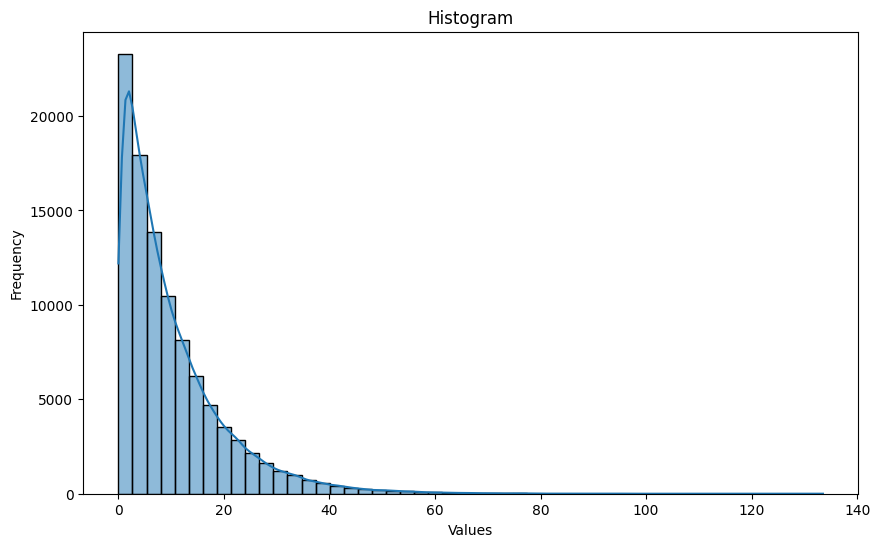

In [27]:
numbers = np.random.exponential(scale=10, size=100000)
plt.figure(figsize=(10, 6))
sns.histplot(numbers, bins=50, kde=True)
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

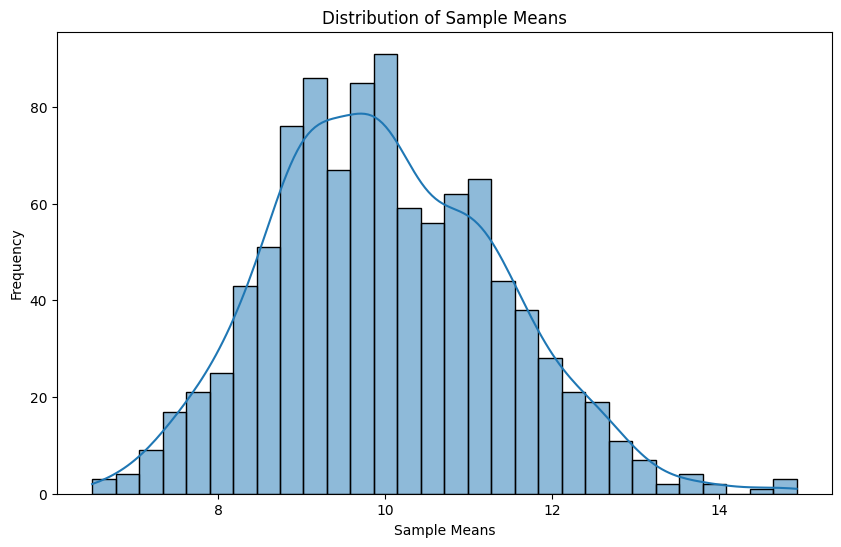

In [28]:
sample_size = 50
n_samples = 1000

sample_means = []

for _ in range(n_samples):
  sample = np.random.choice(numbers, size=sample_size)  # bốc mẫu 50 có hoàn lại
  sample_means.append(np.mean(sample))  # tính trung bình -> array

plt.figure(figsize=(10, 6))
sns.histplot(sample_means, bins=30, kde=True)
plt.xlabel('Sample Means')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means')
plt.show()

In [30]:
group_a = stats.norm.rvs(loc=75, scale=10, size=100)
group_b = stats.norm.rvs(loc=77, scale=12, size=100)
group_c = stats.norm.rvs(loc=76, scale=11, size=100)

mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
mean_c = np.mean(group_c)

print(f'Mean of Group A: {mean_a:.2f}')
print(f'Mean of Group B: {mean_b:.2f}')
print(f'Mean of Group C: {mean_c:.2f}')

Mean of Group A: 75.33
Mean of Group B: 78.84
Mean of Group C: 74.91


In [31]:
f, p = stats.f_oneway(group_a, group_b, group_c)
print(f'f-stat: {f:.3f}')
print(f'p-value: {p:.3f}')

f-stat: 3.723
p-value: 0.025


In [32]:
if p < 0.05:
  print('Reject the null hypothesis: at least 1 group mean is different')
else:
  print('Fail to reject the null hypothesis: no significant difference among 3 groups')

Reject the null hypothesis: at least 1 group mean is different


In [39]:
movie_likes = np.array([[60, 40], [30, 70]])
df_movies = pd.DataFrame(movie_likes, columns=['Action', 'Romantic'], index=['Male', 'Female'])
df_movies

,Action,Romantic
Male,60,40
Female,30,70


In [43]:
chi2, p_value, _, _ = stats.chi2_contingency(df_movies)
print(f'Chi-squared statistic: {chi2:.3f}')
print(f'p-value: {p_value:.5f}')

if p_value < 0.05:
  print('Reject the null hypothesis: there is a significant association between gender and movie preference')
else:
  print('Fail to reject the null hypothesis: there is no significant association between gender and movie preference')

Chi-squared statistic: 16.990
p-value: 0.00004
Reject the null hypothesis: there is a significant association between gender and movie preference
